In [1]:
import torch
import torch.nn as nn
import torch.functional as F
from torch.utils.data import Dataset, DataLoader

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as img
import keyboard
from tqdm import tqdm

In [2]:
# globals
num_hands = 1
tracking_points = 21
tracking_dim = 3

# arch settings
classifier_hidden_dim = 1024
num_action_classes = 3

# hyperparams
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.AdamW
lr = 0.001
batch_size = 128
num_epochs = 5

# torch settings
run_device = torch.device("cuda")

In [3]:
class CameraWrapper:
    """A simple wrapper for an OpenCV VideoCapture object.
    Provides a clean interface to get frames in RGB numpy format.
    """
    def __init__(self, camera_index: int = 0):
        """Initializes the camera.
        
        Args:
            camera_index: The index of the camera to use (e.g., 0 for the default).
        """
        self.cap = cv2.VideoCapture(camera_index)
        if not self.cap.isOpened():
            raise IOError(f"Cannot open camera at index {camera_index}")

    def __call__(self) -> np.ndarray | None:
        """Reads a single frame from the camera and converts it to RGB.
        
        Returns:
            An RGB numpy array if a frame is successfully read, 
            otherwise None (e.g., on stream end or error).
        """
        ret, frame = self.cap.read()
        
        if ret:
            # Convert from BGR (OpenCV default) to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            return frame
        return None

    def release(self):
        """Releases the camera resource."""
        if self.cap.isOpened():
            self.cap.release()

    def __enter__(self):
        """Enter the runtime context related to this object."""
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Exit the runtime context and release the camera."""
        self.release()

In [4]:
class HandTracker:
    """
    MediaPipe Tasks HandLandmarker wrapper that returns torch tensors.

    Output tensor:
      shape: (num_hands, 21, 3)
      coords: normalized x,y in [0,1] (relative to image size), z is model-relative.
    """

    def __init__(
        self,
        model_path: str,
        max_num_hands: int = 2,
        min_hand_detection_confidence: float = 0.5,
        min_hand_presence_confidence: float = 0.5,
        min_tracking_confidence: float = 0.5,
    ):
        self.base_options = python.BaseOptions(model_asset_path=model_path)
        self.options = vision.HandLandmarkerOptions(
            base_options=self.base_options,
            running_mode=vision.RunningMode.VIDEO,
            num_hands=max_num_hands,
            min_hand_detection_confidence=min_hand_detection_confidence,
            min_hand_presence_confidence=min_hand_presence_confidence,
            min_tracking_confidence=min_tracking_confidence,
        )
        self.landmarker = vision.HandLandmarker.create_from_options(self.options)

    def reset(self):
        self.landmarker.close()
        self.landmarker = vision.HandLandmarker.create_from_options(self.options)


    def __call__(self, bgr_frame: np.ndarray, timestamp_ms: int) -> torch.Tensor:
        """
        Args:
            bgr_frame: OpenCV image (H,W,3) uint8 in BGR
            timestamp_ms: monotonically increasing timestamp in milliseconds (required for VIDEO mode)

        Returns:
            torch.FloatTensor of shape (N, 21, 3). If no hands: (0, 21, 3)
        """
        if bgr_frame is None or bgr_frame.ndim != 3 or bgr_frame.shape[2] != 3:
            raise ValueError("bgr_frame must be an HxWx3 BGR image")

        rgb = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = self.landmarker.detect_for_video(mp_image, timestamp_ms=timestamp_ms)

        if not result.hand_landmarks:
            return torch.empty((0, 21, 3), dtype=torch.float32)

        # result.hand_landmarks: list[hands] -> each is list[21] normalized landmarks with x,y,z
        out = np.zeros((len(result.hand_landmarks), 21, 3), dtype=np.float32)
        for h, hand in enumerate(result.hand_landmarks):
            for i, lm in enumerate(hand):
                out[h, i, 0] = lm.x
                out[h, i, 1] = lm.y
                out[h, i, 2] = lm.z

        return torch.from_numpy(out)

    def close(self):
        self.landmarker.close()

In [5]:
class Utils:
    @staticmethod
    def to_bone_offsets(tensor: torch.Tensor) -> torch.Tensor:
        """
        Converts a (2, 21, 3) tensor of absolute coordinates to a tensor of 
        relative bone offsets. The wrist (index 0) becomes (0,0,0).
        
        Args:
            tensor (torch.Tensor): A tensor of shape (2, 21, 3).
        
        Returns:
            torch.Tensor: A tensor of shape (2, 21, 3) containing bone offsets.
        """
        # Create a copy to avoid modifying the original tensor in-place if needed
        offsets = tensor.clone()
        
        # Iterate through the hand dimension (dim 0)
        # Note: This can be vectorized for performance, but explicit loops are clearer for logic
        for i in range(tensor.shape[0]):
            # Set Wrist (index 0) to 0,0,0
            offsets[i, 0, :] = 0
            
            # Standard MediaPipe Hand topology connections (Parent -> Child)
            # 0: Wrist
            # 1-4: Thumb
            # 5-8: Index
            # 9-12: Middle
            # 13-16: Ring
            # 17-20: Pinky
            
            topology = [
                (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
                (0, 5), (5, 6), (6, 7), (7, 8),  # Index
                (0, 9), (9, 10), (10, 11), (11, 12), # Middle
                (0, 13), (13, 14), (14, 15), (15, 16), # Ring
                (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky
            ]
            
            for parent_idx, child_idx in topology:
                # Calculate offset: Child Position - Parent Position
                offsets[i, child_idx, :] = tensor[i, child_idx, :] - tensor[i, parent_idx, :]
                
        return offsets

In [6]:
class HandVisualizer:
    """
    Visualizer for MediaPipe Hand Landmarks returned by HandPoseDataset.
    Plots a 2D view (X, Y) matching the camera perspective.
    """
    
    def __init__(self):
        # Standard MediaPipe Hand topology connections (Parent Index -> Child Index)
        self.topology = [
            (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
            (0, 5), (5, 6), (6, 7), (7, 8),  # Index
            (0, 9), (9, 10), (10, 11), (11, 12), # Middle
            (0, 13), (13, 14), (14, 15), (15, 16), # Ring
            (0, 17), (17, 18), (18, 19), (19, 20), # Pinky
            
            (2, 5), # thumb to index web
            (5, 9), # index to middle web
            (9, 13), # middle to ring web
            (13, 17), # ring to pinky web
            
            (1, 5) # diagonal between thumb to index
        ]

    def show(self, hand_pose):
        """
        Renders a single hand pose.
        
        Args:
            hand_pose (torch.Tensor): Tensor of shape (1, 21, 3).
        """
        # Convert to numpy and squeeze the batch dimension
        if isinstance(hand_pose, torch.Tensor):
            landmarks = hand_pose.squeeze(0).cpu().numpy()
        else:
            landmarks = hand_pose.squeeze(0)

        # Setup the 2D plot
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Set background to black (0, 0, 0)
        fig.patch.set_facecolor('#000000')
        ax.set_facecolor('#000000')

        # We need X and Y. In your data, X is index 0, Y is index 1
        xs = landmarks[:, 0]
        ys = landmarks[:, 1]

        # Plot the skeleton (bones) in bright blue (0, 0, 255)
        # Note: Matplotlib uses RGB 0-1, so 255 is 1.0
        for parent_idx, child_idx in self.topology:
            p1 = landmarks[parent_idx]
            p2 = landmarks[child_idx]
            
            ax.plot(
                [p1[0], p2[0]], 
                [p1[1], p2[1]], 
                c=(0, 0, 1), # Bright Blue
                linewidth=2
            )

        # Plot the landmarks as slightly dimmer, transparent blue squares
        # Dimmer blue (0, 0, 0.8), alpha 0.5
        ax.scatter(
            xs, ys, 
            c=(0, 0, 0.8), 
            marker='s', # 's' for square
            alpha=0.5,  # Transparency
            s=80        # Size of the square
        )

        # Set limits to match image aspect ratio (assuming normalized 0-1 coordinates)
        ax.set_xlim(0, 1)
        ax.set_ylim(1, 0) # Invert Y to match image coordinates (0 at top)
        
        # Hide axes for a clean look
        ax.axis('off')

        plt.tight_layout()
        plt.show()

In [7]:
class HandPoseDataset(Dataset):
    def __init__(self, camera: CameraWrapper, hand_tracker: HandTracker, stop_key=' ', action_keys_list=['a', 's', 'd']):
        self.hand_poses = []
        self.hand_actions = []
        
        # this thing is used to tell where we switched from gathering to not gathering and the other way around for logging
        self.gather_flag_1 = False
        self.gather_flag_2 = self.gather_flag_1
        
        self.start_time = time.time()
        
        print(f"starting gathering loop, stop by pressing '{stop_key}'")
        
        # loop until the hault key isnt pressed
        while not keyboard.is_pressed(stop_key):
            # logging
            if self.gather_flag_1 != self.gather_flag_2:
                if self.gather_flag_1:
                    print("started gathering")
                else:
                    print("stopped gathering")

                self.gather_flag_2 = self.gather_flag_1
            
            self.gather_flag_1 = False
                
            # check which key, or if at all is pressed
            for self.key in action_keys_list:
                if keyboard.is_pressed(self.key):
                    self.current_key = self.key
                    break
            else:
                continue
            
            # if a key is indeed pressed get the hand position right now from the camera
            self.np_image = camera()
            self.hand_pose = hand_tracker(self.np_image, int((time.time() - self.start_time) * 1000))
            
            # check if no more or less than 1 hands were detected
            if len(self.hand_pose) != num_hands:
                continue
            
            self.hand_poses.append(self.hand_pose)
            self.hand_actions.append(torch.diag(torch.ones(len(action_keys_list)))[action_keys_list.index(self.current_key)]) # onehot encode currentkey's index
            
            self.gather_flag_1 = True
            
    def __len__(self):
        return len(self.hand_poses)
    
    def __getitem__(self, index):
        return self.hand_poses[index], self.hand_actions[index]

In [8]:
class PoseClassifier(nn.Module):
    def __init__(self):
        super(PoseClassifier, self).__init__()
        
        self.fc1 = nn.Linear(num_hands * tracking_points * tracking_dim, classifier_hidden_dim)
        self.fc2 = nn.Linear(classifier_hidden_dim, classifier_hidden_dim)
        self.fc3 = nn.Linear(classifier_hidden_dim, classifier_hidden_dim)
        self.fc4 = nn.Linear(classifier_hidden_dim, num_action_classes)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        
        return x

In [9]:
pose_classifier = PoseClassifier().to(run_device)

In [10]:
hand_tracker = HandTracker(model_path="hand_landmarker.task")
camera = CameraWrapper(1)

In [11]:
optim = optim(pose_classifier.parameters(), lr=lr)

In [12]:
dset = HandPoseDataset(camera, hand_tracker)

starting gathering loop, stop by pressing ' '
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering
started gathering
stopped gathering


In [13]:
train_loader = DataLoader(dataset=dset, batch_size=batch_size, shuffle=True)

In [14]:
loss_list = []

In [24]:
for _ in tqdm(range(num_epochs)):
    for batch in train_loader:
        output = pose_classifier(batch[0].to(run_device))
        loss = loss_fn(output, batch[1].to(run_device))
        
        optim.zero_grad()
        loss.backward()
        optim.step()
        
        # logging
        loss_list.append(loss.item())

100%|██████████| 5/5 [00:00<00:00, 31.06it/s]


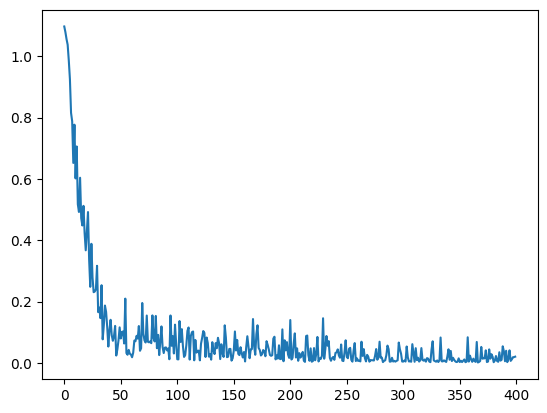

In [25]:
plt.plot(loss_list)

In [26]:
hand_tracker.reset()
start_time = time.time()

while True:
    # run the hand tracker model
    np_image = camera()
    hand_pose = hand_tracker(np_image, int((time.time() - start_time) * 1000))
    
    # check if we got a lock on one hand
    if (hand_pose.size(0) != num_hands):
        continue
    
    # run the result thru the model
    hand_pose = hand_pose.to(run_device)
    result = pose_classifier(hand_pose.unsqueeze(0))
    
    print(result)

tensor([[ 4.0158, -0.6651, -3.8387]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 4.1342, -0.6621, -4.0068]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 4.8442, -0.2360, -5.2290]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 5.1494, -0.5149, -5.2957]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 6.0686, -0.5279, -6.2973]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 6.5742, -0.6140, -6.7859]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 7.1291, -0.6187, -7.4003]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 7.9253, -0.3916, -8.5086]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 7.7423, -0.5734, -8.1198]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 8.2348, -0.5486, -8.6955]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 8.5897, -0.5006, -9.1339]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[ 8.4024, -0.4446, -8.98

KeyboardInterrupt: 

In [ ]:
time.sleep(3)
test_gesture = hand_tracker(camera(), int(time.time() * 1000))

In [ ]:
test_gesture